**V-Plot Formation of Protected DNA Fragments**

When a protein binds to DNA, the bound region becomes protected from nucleases, which typically cleave unprotected DNA. As a result, sequencing such fragments reveals a V-shaped pattern when plotted based on fragment size and their position relative to the protein binding site.

Input:

A tab-separated file where each line contains alignment information. Example line:

2	chr1	90919	91937	chr1:91382-91550|carroll_ctcf_mcf7_v45m`2_GTGGCACCAGGTGGCAGCA	16.2951	+	chr1	90838	91006	IH02_00.pairs@15152	168	+

Task:

For each line, compute the following:

C1 = center of the protein binding site = (Column 3 + Column 4) / 2

C2 = center of the DNA fragment = (Column 9 + Column 10) / 2

X = C2 - C1 (distance of fragment from the protein binding center)

Y = Column 10 - Column 9 (length of the fragment)

Z = Count of how many times this (X, Y) pair appears

Output:

Create a 2D heatmap using X and Y as axes and Z as intensity (color).
The result should visualize the V-form pattern of DNA protection around protein binding sites.

Total unique (X, Y) pairs: 280653


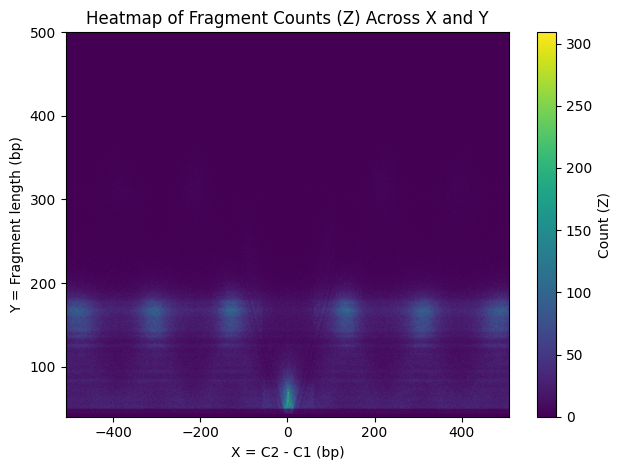

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

input_file = "/mnt/mapped.bed"

cnts = Counter()

with open(input_file, 'r') as file:
    for line_num, line in enumerate(file):
        col = line.strip().split('\t')

        if len(col) >= 10:
          c1 = (int(col[2]) + int(col[3])) / 2
          c2 = (int(col[8]) + int(col[9])) / 2

          x = int(c2 - c1)
          y = int(col[9]) - int(col[8])
          cnts[(x, y)] += 1

print(f"Total unique (X, Y) pairs: {len(cnts)}")

x_vals = sorted({coord[0] for coord in cnts})
y_vals = sorted({coord[1] for coord in cnts})

x_ind = {val: idx for idx, val in enumerate(x_vals)}
y_ind = {val: idx for idx, val in enumerate(y_vals)}

mat = np.zeros((len(y_vals), len(x_vals)))

for (x, y), z in cnts.items():
    row = y_ind[y]
    col = x_ind[x]
    mat[row, col] = z

fig, ax = plt.subplots()
heatmap = ax.imshow(mat, aspect='auto', origin='lower', extent=[min(x_vals), max(x_vals), min(y_vals), max(y_vals)])

ax.set_xlabel("X = C2 - C1 (bp)")
ax.set_ylabel("Y = Fragment length (bp)")
ax.set_title("Heatmap of Fragment Counts (Z) Across X and Y")

fig.colorbar(heatmap, label="Count (Z)")

plt.tight_layout()
plt.show()